In [1]:
import sys
print(sys.executable)

/Users/srishtisindgi/rainfall-ml-project/venv/bin/python


# Rainfall Prediction Using Machine Learning

## Objective: Predict daily rainfall using historical weather data from NASA POWER dataset.

Target Variable:
PRECTOTCORR → Daily Rainfall (mm)

Workflow:
1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
6. Feature Selection
7. PCA (Dimensionality Reduction)
8. Train/Test Split
9. Model Training
10. Model Evaluation
11. Model Comparison
12. Future Rainfall Prediction

# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

import warnings
warnings.filterwarnings("ignore")

# 2. Load Dataset

In [3]:
with open("../data/rainfall.csv") as f:
    for i in range(10):
        print(f.readline())

-BEGIN HEADER-

NASA/POWER Source Native Resolution Daily Data 

Dates (month/day/year): 01/01/1995 through 12/31/2025 in LST

Location: latitude  18.8209   longitude 98.9899 

elevation from MERRA-2: Average for 0.5 x 0.625 degree lat/lon region = 759.08 meters

The value for missing source data that cannot be computed or is outside of the sources availability range: -999 

parameter(s): 

ALLSKY_SFC_SW_DWN     CERES SYN1deg All Sky Surface Shortwave Downward Irradiance (MJ/m^2/day) 

ALLSKY_SFC_SW_DNI     CERES SYN1deg All Sky Surface Shortwave Downward Direct Normal Irradiance (MJ/m^2/day) 

T2M                   MERRA-2 Temperature at 2 Meters (C) 



In [4]:
with open("../data/rainfall.csv") as f:
    for i, line in enumerate(f):
        if "YEAR" in line:
            print("Header starts at line:", i)
            break

Header starts at line: 20


In [5]:
with open("../data/rainfall.csv") as f:
    for i, line in enumerate(f):
        if "YEAR" in line:
            header_row = i
            break

df = pd.read_csv("../data/rainfall.csv", skiprows=header_row)
df.head()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,QV2M,WS2M,GWETTOP
0,1995,1,17.11,-999.0,17.73,13.82,15.77,23.15,12.75,0.0,79.16,10.71,0.44,0.61
1,1995,2,16.33,-999.0,18.56,15.34,16.95,23.46,14.57,0.0,82.93,11.77,0.35,0.61
2,1995,3,18.10,-999.0,18.24,13.47,15.85,23.87,12.62,0.0,75.39,10.46,0.35,0.61
3,1995,4,19.50,-999.0,18.36,13.77,16.06,24.54,12.68,0.0,76.46,10.71,0.42,0.60
4,1995,5,17.75,-999.0,16.32,14.02,15.17,20.63,12.91,0.0,85.78,10.76,0.11,0.60


# 3. Dataset Overview

In [6]:
df.shape

(11323, 14)

In [7]:
df.columns

Index(['YEAR', 'DOY', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'T2M',
       'T2MDEW', 'T2MWET', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'QV2M',
       'WS2M', 'GWETTOP'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11323 entries, 0 to 11322
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   YEAR               11323 non-null  int64  
 1   DOY                11323 non-null  int64  
 2   ALLSKY_SFC_SW_DWN  11323 non-null  float64
 3   ALLSKY_SFC_SW_DNI  11323 non-null  float64
 4   T2M                11323 non-null  float64
 5   T2MDEW             11323 non-null  float64
 6   T2MWET             11323 non-null  float64
 7   T2M_MAX            11323 non-null  float64
 8   T2M_MIN            11323 non-null  float64
 9   PRECTOTCORR        11323 non-null  float64
 10  RH2M               11323 non-null  float64
 11  QV2M               11323 non-null  float64
 12  WS2M               11323 non-null  float64
 13  GWETTOP            11323 non-null  float64
dtypes: float64(12), int64(2)
memory usage: 1.2 MB


In [9]:
df.describe()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,QV2M,WS2M,GWETTOP
count,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000,11323.000000
mean,2010.000000,183.129294,17.295797,-187.444673,23.129722,17.419936,20.274825,28.795779,18.504557,3.464473,74.711486,14.008993,0.146917,0.590506
std,8.944825,105.445637,10.332846,401.299990,2.954370,4.529072,3.142013,3.691925,3.355888,6.308230,15.646668,3.565378,0.137356,0.112271
min,1995.000000,1.000000,-999.000000,-999.000000,8.400000,-0.740000,4.000000,11.170000,3.180000,0.000000,27.260000,3.910000,0.000000,0.280000
25%,2002.000000,92.000000,14.940000,0.870000,21.400000,14.130000,17.920000,26.390000,16.030000,0.000000,64.415000,10.940000,0.030000,0.500000
50%,2010.000000,183.000000,17.590000,7.340000,23.520000,19.280000,21.650000,28.390000,19.810000,0.590000,80.300000,15.220000,0.100000,0.590000
75%,2018.000000,274.000000,19.990000,15.055000,24.830000,21.170000,22.745000,30.915000,21.060000,4.310000,87.000000,17.130000,0.250000,0.670000
max,2025.000000,366.000000,27.540000,32.020000,32.870000,23.840000,25.260000,40.520000,26.440000,85.630000,98.070000,20.150000,0.600000,0.970000


The dataset contains meteorological variables collected from the NASA POWER database.
These variables include temperature, humidity, wind speed, solar radiation and rainfall.

# 4. Data Cleaning

NASA datasets use -999 to represent missing values. Replace them with NaN.

In [10]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,QV2M,WS2M,GWETTOP
0,1995,1,17.11,NaN,17.73,13.82,15.77,23.15,12.75,0.0,79.16,10.71,0.44,0.61
1,1995,2,16.33,NaN,18.56,15.34,16.95,23.46,14.57,0.0,82.93,11.77,0.35,0.61
2,1995,3,18.10,NaN,18.24,13.47,15.85,23.87,12.62,0.0,75.39,10.46,0.35,0.61
3,1995,4,19.50,NaN,18.36,13.77,16.06,24.54,12.68,0.0,76.46,10.71,0.42,0.60
4,1995,5,17.75,NaN,16.32,14.02,15.17,20.63,12.91,0.0,85.78,10.76,0.11,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11318,2025,361,17.52,NaN,18.28,15.17,16.73,23.58,14.12,0.0,83.45,11.65,0.27,0.68
11319,2025,362,17.48,NaN,18.72,14.94,16.83,23.64,14.33,0.0,80.05,11.47,0.28,0.67
11320,2025,363,17.87,NaN,18.69,14.85,16.77,23.60,13.42,0.0,79.66,11.41,0.34,0.67
11321,2025,364,16.61,NaN,18.67,14.17,16.42,23.76,13.55,0.0,76.33,10.95,0.35,0.67


In [11]:
df.isnull().sum()

YEAR                    0
DOY                     0
ALLSKY_SFC_SW_DWN       1
ALLSKY_SFC_SW_DNI    2224
T2M                     0
T2MDEW                  0
T2MWET                  0
T2M_MAX                 0
T2M_MIN                 0
PRECTOTCORR             0
RH2M                    0
QV2M                    0
WS2M                    0
GWETTOP                 0
dtype: int64

In [12]:
df = df.ffill()
df = df.bfill()

In [13]:
df.isnull().sum()

YEAR                 0
DOY                  0
ALLSKY_SFC_SW_DWN    0
ALLSKY_SFC_SW_DNI    0
T2M                  0
T2MDEW               0
T2MWET               0
T2M_MAX              0
T2M_MIN              0
PRECTOTCORR          0
RH2M                 0
QV2M                 0
WS2M                 0
GWETTOP              0
dtype: int64

# 5. Remove Invalid Rainfall Values
Rainfall cannot be negative.

In [14]:
df = df[df["PRECTOTCORR"] >= 0]

# 6. Feature Engineering
Convert Day Of Year (DOY) → Date.

In [15]:
df["DATE"] = pd.to_datetime(df["YEAR"].astype(str)) + pd.to_timedelta(df["DOY"] - 1, unit="D")

In [16]:
df["MONTH"] = df["DATE"].dt.month
df["DAY"] = df["DATE"].dt.day

In [17]:
df.head()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,QV2M,WS2M,GWETTOP,DATE,MONTH,DAY
0,1995,1,17.11,15.2,17.73,13.82,15.77,23.15,12.75,0.0,79.16,10.71,0.44,0.61,1995-01-01,1,1
1,1995,2,16.33,15.2,18.56,15.34,16.95,23.46,14.57,0.0,82.93,11.77,0.35,0.61,1995-01-02,1,2
2,1995,3,18.10,15.2,18.24,13.47,15.85,23.87,12.62,0.0,75.39,10.46,0.35,0.61,1995-01-03,1,3
3,1995,4,19.50,15.2,18.36,13.77,16.06,24.54,12.68,0.0,76.46,10.71,0.42,0.60,1995-01-04,1,4
4,1995,5,17.75,15.2,16.32,14.02,15.17,20.63,12.91,0.0,85.78,10.76,0.11,0.60,1995-01-05,1,5


In [18]:
df.columns

Index(['YEAR', 'DOY', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'T2M',
       'T2MDEW', 'T2MWET', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'QV2M',
       'WS2M', 'GWETTOP', 'DATE', 'MONTH', 'DAY'],
      dtype='str')

In [19]:
df = df.sort_values("DATE")
df = df.reset_index(drop=True)

In [20]:
df[["YEAR","DOY","DATE"]].head()

,YEAR,DOY,DATE
0,1995,1,1995-01-01
1,1995,2,1995-01-02
2,1995,3,1995-01-03
3,1995,4,1995-01-04
4,1995,5,1995-01-05


In [21]:
df["RAIN_LAG1"] = df["PRECTOTCORR"].shift(1)
df["RAIN_LAG2"] = df["PRECTOTCORR"].shift(2)
df["RAIN_LAG3"] = df["PRECTOTCORR"].shift(3)

df = df.dropna()

In [22]:
df[["PRECTOTCORR","RAIN_LAG1","RAIN_LAG2","RAIN_LAG3"]].head()

,PRECTOTCORR,RAIN_LAG1,RAIN_LAG2,RAIN_LAG3
3,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0


In [23]:
df["RAIN_ROLLING3"] = df["PRECTOTCORR"].rolling(window=3).mean()
df["RAIN_ROLLING7"] = df["PRECTOTCORR"].rolling(window=7).mean()

In [24]:
df = df.dropna()

In [25]:
df.head()

,YEAR,DOY,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,T2M,T2MDEW,T2MWET,T2M_MAX,T2M_MIN,PRECTOTCORR,...,WS2M,GWETTOP,DATE,MONTH,DAY,RAIN_LAG1,RAIN_LAG2,RAIN_LAG3,RAIN_ROLLING3,RAIN_ROLLING7
9,1995,10,18.81,15.2,18.87,12.40,15.64,24.76,13.37,0.0,...,0.47,0.60,1995-01-10,1,10,0.0,0.0,0.0,0.0,0.0
10,1995,11,19.19,15.2,18.82,11.63,15.22,24.75,12.38,0.0,...,0.40,0.59,1995-01-11,1,11,0.0,0.0,0.0,0.0,0.0
11,1995,12,18.50,15.2,18.98,12.91,15.95,25.15,14.01,0.0,...,0.52,0.59,1995-01-12,1,12,0.0,0.0,0.0,0.0,0.0
12,1995,13,17.78,15.2,19.53,14.64,17.08,24.77,15.43,0.0,...,0.21,0.58,1995-01-13,1,13,0.0,0.0,0.0,0.0,0.0
13,1995,14,14.58,15.2,19.04,15.47,17.26,25.03,13.93,0.0,...,0.32,0.58,1995-01-14,1,14,0.0,0.0,0.0,0.0,0.0


In [26]:
df.columns

Index(['YEAR', 'DOY', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'T2M',
       'T2MDEW', 'T2MWET', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'QV2M',
       'WS2M', 'GWETTOP', 'DATE', 'MONTH', 'DAY', 'RAIN_LAG1', 'RAIN_LAG2',
       'RAIN_LAG3', 'RAIN_ROLLING3', 'RAIN_ROLLING7'],
      dtype='str')

# 7. Exploratory Data Analysis
## Rainfall Distribution

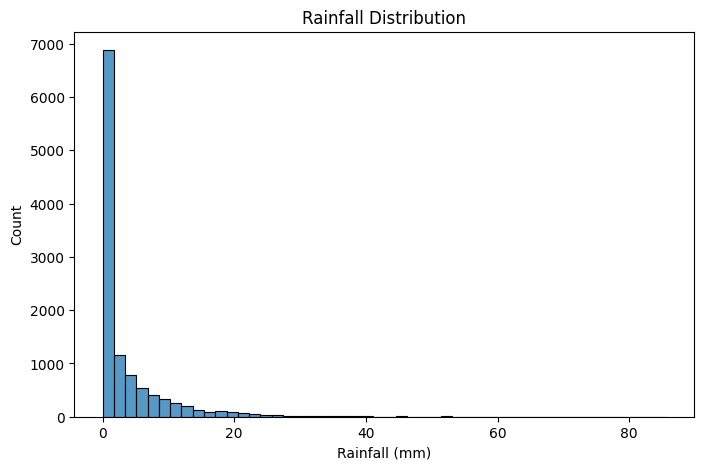

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.show()

## Rainfall Over Time

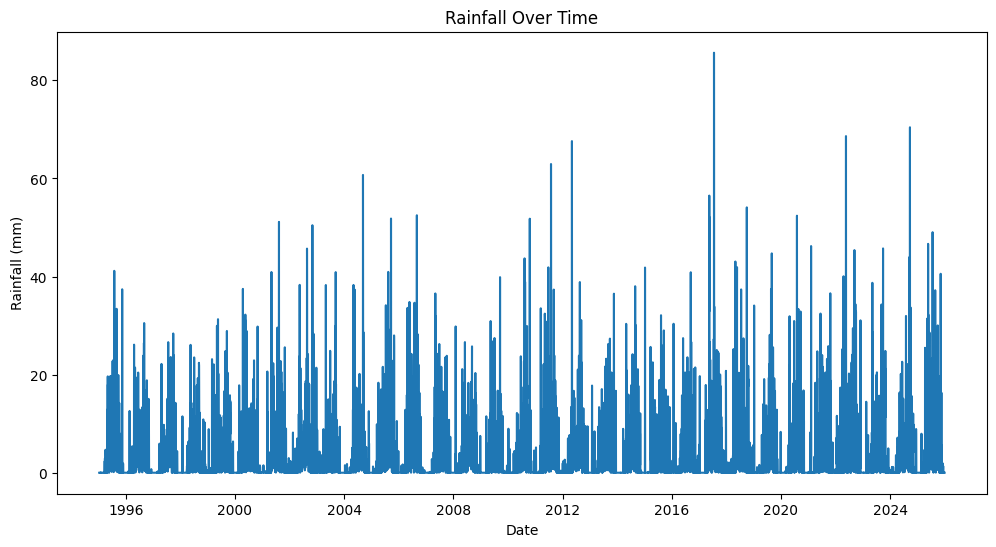

In [28]:
plt.figure(figsize=(12,6))
plt.plot(df["DATE"], df["PRECTOTCORR"])
plt.title("Rainfall Over Time")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.show()

## Monthly Rainfall Distribution

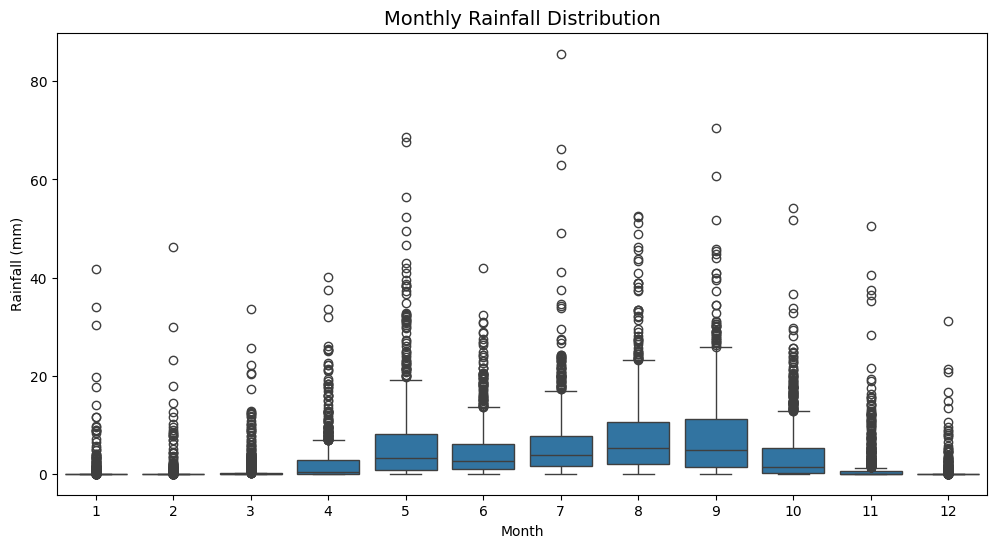

In [29]:
plt.figure(figsize=(12,6))

sns.boxplot(x="MONTH", y="PRECTOTCORR", data=df)

plt.title("Monthly Rainfall Distribution", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

plt.show()

## Average Monthly Rainfall

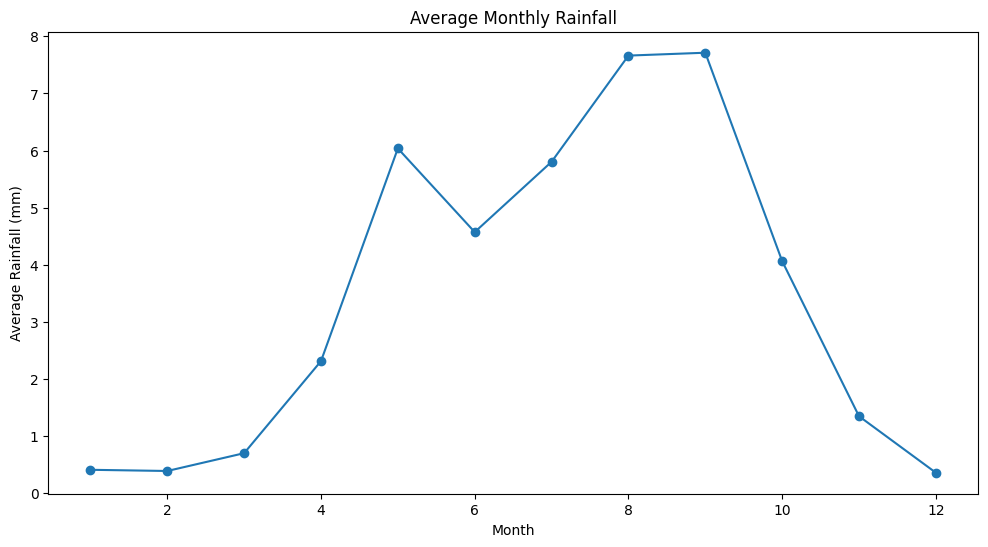

In [30]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].mean()

plt.figure(figsize=(12,6))
monthly_rain.plot(marker='o')

plt.title("Average Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")

plt.show()

## Correlation Analysis

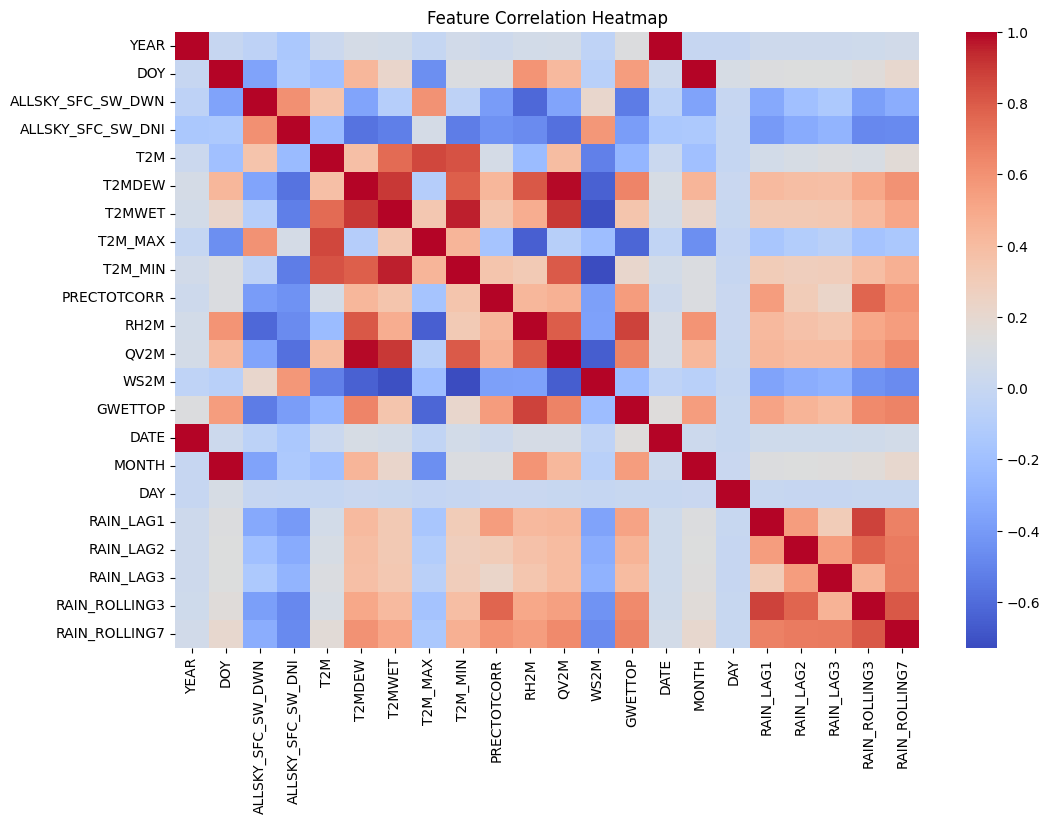

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

This helps identify features strongly correlated with rainfall.

# 8. Feature Selection
Define features.

In [32]:
features = [
"ALLSKY_SFC_SW_DWN",
"T2M",
"T2MDEW",
"T2MWET",
"T2M_MAX",
"T2M_MIN",
"RH2M",
"QV2M",
"WS2M",
"GWETTOP",
"MONTH",
"DAY",
"RAIN_LAG1",
"RAIN_LAG2",
"RAIN_LAG3",
"RAIN_ROLLING3",
"RAIN_ROLLING7"
]

# 9. Feature Scaling
Scaling improves ML model performance.

In [53]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'X_train_scaled' is not defined

# 10. PCA (Dimensionality Reduction)
## Reduce dimensionality while preserving variance.

In [34]:
pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Features:", X.shape)
print("Reduced Features:", X_pca.shape)

NameError: name 'X_train_scaled' is not defined

## Plot explained variance.

In [35]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("PCA Variance Explained")
plt.show()

AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

### 11. Train/Test Split

To simulate real-world forecasting, we use a time-based split.

Training Data: 1995–2020  
Testing Data: 2021–2025

In [36]:
# ---------------------------
# Train/Test Split (Time-based)
# ---------------------------

train_df = df[df["YEAR"] <= 2020]
test_df = df[df["YEAR"] > 2020]

print("Train samples:", train_df.shape)
print("Test samples:", test_df.shape)

Train samples: (9488, 22)
Test samples: (1826, 22)


In [37]:
features = [
    'ALLSKY_SFC_SW_DWN',
    'ALLSKY_SFC_SW_DNI',
    'T2M',
    'T2MDEW',
    'T2MWET',
    'T2M_MAX',
    'T2M_MIN',
    'RH2M',
    'QV2M',
    'WS2M',
    'GWETTOP',
    'RAIN_LAG1',
    'RAIN_LAG2',
    'RAIN_LAG3',
    'RAIN_ROLLING3',
    'RAIN_ROLLING7'
]

In [38]:
X_train = train_df[features]
y_train = train_df["PRECTOTCORR"]

X_test = test_df[features]
y_test = test_df["PRECTOTCORR"]

print(X_train.shape)
print(X_test.shape)

(9488, 16)
(1826, 16)


# 12. Model Training

Multiple machine learning models are trained to predict daily rainfall.

Models used:
- Decision Tree
- Random Forest
- Support Vector Regression

In [39]:
!pip install xgboost

In [40]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [41]:
# Initialize models

dt_model = DecisionTreeRegressor(random_state=42)

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

svr_model = SVR()

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [42]:
# Train models

dt_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

svr_model.fit(X_train, y_train)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [43]:
dt_pred = dt_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

svr_pred = svr_model.predict(X_test)

xgb_pred = xgb_model.predict(X_test)

# 13. Model Evaluation

Models are evaluated using:

- RMSE
- MAE
- R² Score

In [54]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [55]:
import numpy as np

def evaluate_model(y_true, y_pred):

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

In [56]:
dt_rmse, dt_mae, dt_r2 = evaluate_model(y_test, dt_pred)

rf_rmse, rf_mae, rf_r2 = evaluate_model(y_test, rf_pred)

svr_rmse, svr_mae, svr_r2 = evaluate_model(y_test, svr_pred)

xgb_rmse, xgb_mae, xgb_r2 = evaluate_model(y_test, xgb_pred)

In [57]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVR", "XGBoost"],
    "RMSE": [dt_rmse, rf_rmse, svr_rmse, xgb_rmse],
    "MAE": [dt_mae, rf_mae, svr_mae, xgb_mae],
    "R2 Score": [dt_r2, rf_r2, svr_r2, xgb_r2]
})

results

,Model,RMSE,MAE,R2 Score
0,Decision Tree,3.736747,1.214743,0.740917
1,Random Forest,2.218194,0.794695,0.908704
2,SVR,2.507305,1.131099,0.883355
3,XGBoost,1.976104,0.650386,0.927545


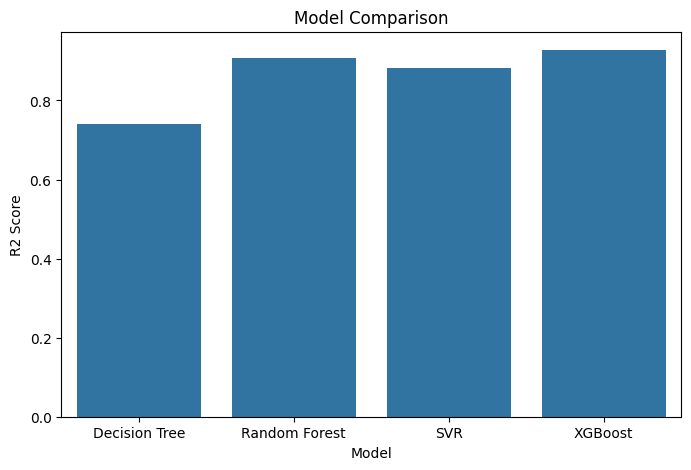

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("Model Comparison")

plt.show()

In [84]:
plt.savefig("../outputs/model_comparison.png", dpi=300)

<Figure size 640x480 with 0 Axes>

### Best Model Selection

Among all evaluated models, XGBoost achieved the best performance with the
lowest RMSE and highest R² score (0.93).

XGBoost is a gradient boosting algorithm that builds trees sequentially,
allowing it to capture complex nonlinear relationships in meteorological data.

Therefore, XGBoost is selected as the final model for rainfall prediction.

Random Forest also performed strongly (R² = 0.91) and provided useful feature importance insights.

In [59]:
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
14,RAIN_ROLLING3,0.601953
10,GWETTOP,0.141506
12,RAIN_LAG2,0.121260
11,RAIN_LAG1,0.090888
7,RH2M,0.006433
13,RAIN_LAG3,0.006182
6,T2M_MIN,0.004823
0,ALLSKY_SFC_SW_DWN,0.004263
15,RAIN_ROLLING7,0.004051
9,WS2M,0.003626


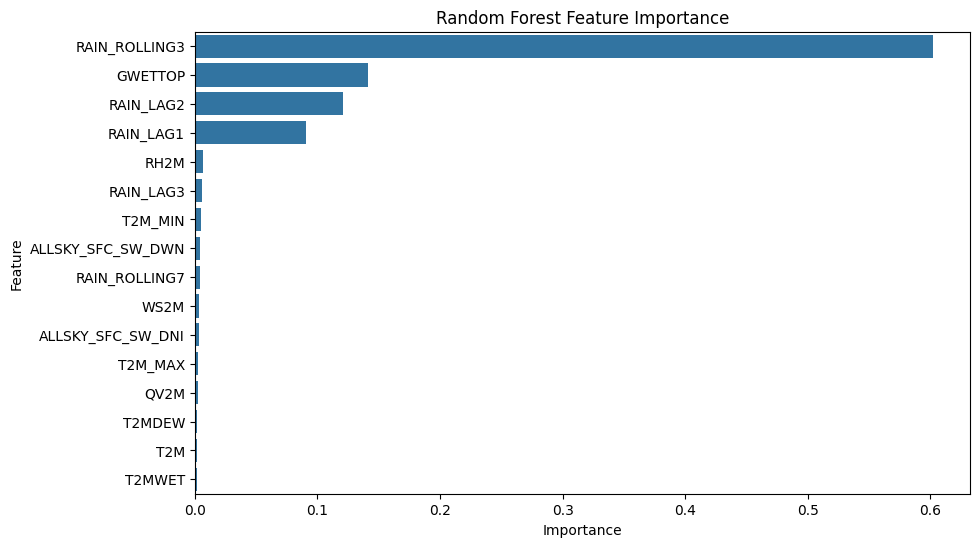

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Random Forest Feature Importance")

plt.show()

### Feature Importance Analysis

The most influential feature was the 3-day rolling rainfall average,
indicating strong temporal dependency in rainfall patterns.

Other important predictors include soil moisture (GWETTOP) and
lagged rainfall values from previous days.

Meteorological variables such as temperature and humidity showed
lower importance, suggesting that recent rainfall history plays a
dominant role in predicting daily precipitation.

One limitation of the model is that it relies heavily on recent rainfall
patterns. While this improves short-term prediction accuracy, it may
reduce the model’s ability to predict rainfall events purely from
meteorological conditions.

In [63]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
14,RAIN_ROLLING3,0.373502
10,GWETTOP,0.238186
12,RAIN_LAG2,0.096749
11,RAIN_LAG1,0.062475
7,RH2M,0.061451
15,RAIN_ROLLING7,0.039684
13,RAIN_LAG3,0.024296
9,WS2M,0.022770
6,T2M_MIN,0.020470
1,ALLSKY_SFC_SW_DNI,0.012578


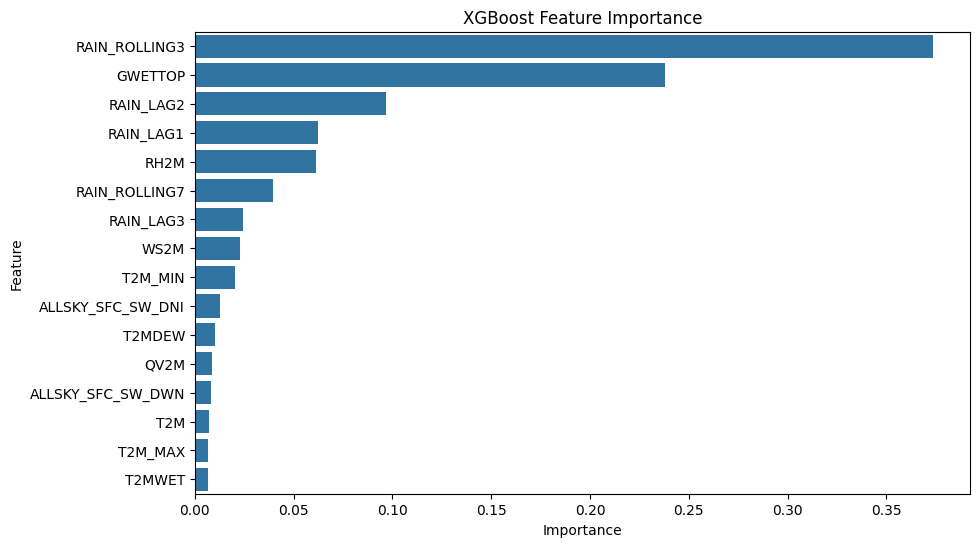

In [64]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_importance
)

plt.title("XGBoost Feature Importance")

plt.show()

In [68]:
predictions = test_df[["YEAR","DOY"]].copy()

predictions["Actual_Rainfall"] = y_test.values
predictions["Predicted_Rainfall"] = xgb_pred

predictions.head()

,YEAR,DOY,Actual_Rainfall,Predicted_Rainfall
9497,2021,1,0.0,0.022527
9498,2021,2,0.0,0.008805
9499,2021,3,0.0,-0.001726
9500,2021,4,0.0,-0.001489
9501,2021,5,0.0,-0.001489


In [79]:
predictions = pd.DataFrame({
    "Actual_Rainfall": y_test,
    "Predicted_Rainfall": xgb_pred
})

predictions.to_csv("../outputs/predictions.csv", index=False)

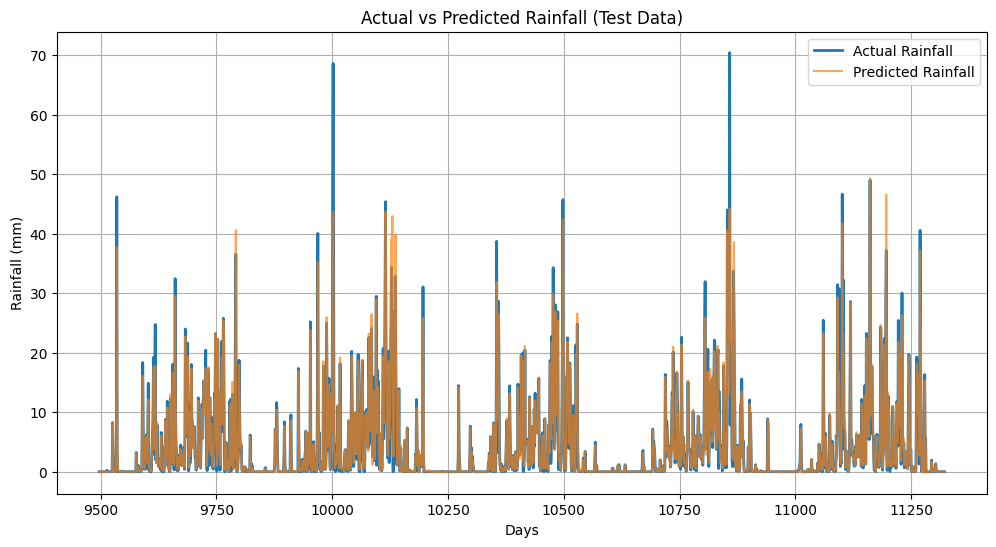

In [71]:
plt.figure(figsize=(12,6))

plt.plot(predictions["Actual_Rainfall"], label="Actual Rainfall", linewidth=2)
plt.plot(predictions["Predicted_Rainfall"], label="Predicted Rainfall", alpha=0.7)

plt.title("Actual vs Predicted Rainfall (Test Data)")
plt.xlabel("Days")
plt.ylabel("Rainfall (mm)")

plt.legend()
plt.grid(True)

plt.show()

In [80]:
plt.savefig("../outputs/actual_vs_predicted.png", dpi=300)

<Figure size 640x480 with 0 Axes>

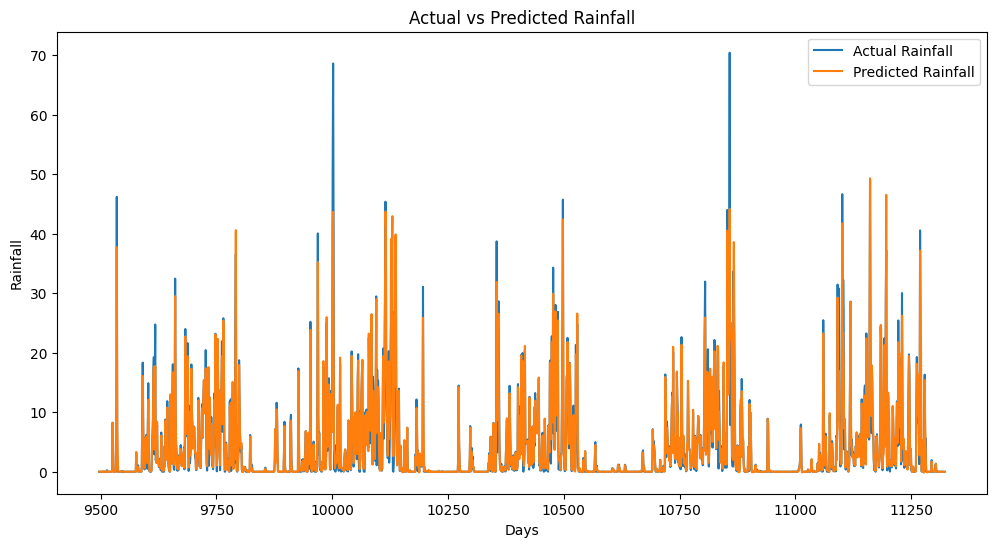

In [72]:
plt.figure(figsize=(12,6))

plt.plot(predictions["Actual_Rainfall"], label="Actual Rainfall")
plt.plot(predictions["Predicted_Rainfall"], label="Predicted Rainfall")

plt.title("Actual vs Predicted Rainfall")
plt.xlabel("Days")
plt.ylabel("Rainfall")

plt.legend()

plt.show()

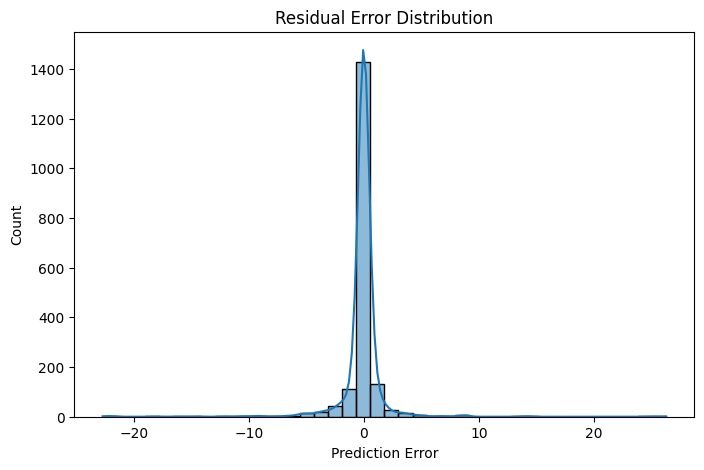

In [75]:
residuals = y_test - xgb_pred

plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=40, kde=True)

plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")

plt.show()

In [81]:
plt.savefig("../outputs/residual_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [76]:
import pickle

with open("../models/rainfall_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("Model saved successfully")

Model saved successfully


In [77]:
# Load model

model = pickle.load(open("../models/rainfall_model.pkl","rb"))

# Example input sample
sample_input = [[
    15.2, 8.3, 28.1, 22.3, 24.5, 31.2, 21.4,
    80.1, 0.018, 3.5, 0.42,
    5.2, 4.8, 3.9, 4.6, 5.1
]]

prediction = model.predict(sample_input)

print("Predicted Rainfall:", prediction[0])

Predicted Rainfall: 4.1255183


In [85]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [86]:
train_pred = xgb_model.predict(X_train)

In [87]:
test_pred = xgb_model.predict(X_test)

In [88]:
train_r2 = r2_score(y_train, train_pred)

train_mse = mean_squared_error(y_train, train_pred)

train_rmse = np.sqrt(train_mse)

train_mae = mean_absolute_error(y_train, train_pred)

print("Training R2:", train_r2)
print("Training RMSE:", train_rmse)
print("Training MAE:", train_mae)
print("Training MSE:", train_mse)

Training R2: 0.9994768059865856
Training RMSE: 0.1391393322569502
Training MAE: 0.09050305237956087
Training MSE: 0.019359753780909976


In [89]:
test_r2 = r2_score(y_test, test_pred)

test_mse = mean_squared_error(y_test, test_pred)

test_rmse = np.sqrt(test_mse)

test_mae = mean_absolute_error(y_test, test_pred)

print("Test R2:", test_r2)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test MSE:", test_mse)

Test R2: 0.9275445262196147
Test RMSE: 1.976103709832931
Test MAE: 0.6503863958808639
Test MSE: 3.9049858720154726


In [90]:
import pandas as pd

results_table = pd.DataFrame({
    "Metric": ["R2 Score", "RMSE", "MAE", "MSE"],
    "Training Set": [train_r2, train_rmse, train_mae, train_mse],
    "Test Set": [test_r2, test_rmse, test_mae, test_mse]
})

results_table

,Metric,Training Set,Test Set
0,R2 Score,0.999477,0.927545
1,RMSE,0.139139,1.976104
2,MAE,0.090503,0.650386
3,MSE,0.019360,3.904986
